# Sanity Check — Summary Articles: Dialect Identification
Run the spelling-marker and POS-n-gram classifiers over every file in `summary_articles/`,
then evaluate how well the predicted dialect matches the ground-truth outlet label.

In [1]:
import sys, json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

PROJECT = Path('/Users/david/Documents/MLDS/Sem 4/NLP/FInal Project ')
sys.path.insert(0, str(PROJECT))

from helpers.spelling_markers import load_spelling_markers, compute_lsr, find_switches, strip_quotes
from helpers.dialect_classifier import build_classifier, scores_to_probs
from helpers.bert_dialect_classifier import load_bert_classifier, evaluate_dialect_bert

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# Train the Bayesian POS n-gram classifier on the full articles/ training set
clf = build_classifier(str(PROJECT / 'articles'))

Loading spaCy model (en_core_web_sm) …



Loading corpus from '/Users/david/Documents/MLDS/Sem 4/NLP/FInal Project /articles' …
  US: 50 articles
  UK: 50 articles
  AUS: 50 articles

Building POS n-gram distributions …
  [US] tagging 50 articles …


/opt/anaconda3/lib/python3.12/site-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


         → 6,287 unique n-grams | 78,730 total occurrences
  [UK] tagging 50 articles …


         → 5,997 unique n-grams | 58,600 total occurrences
  [AUS] tagging 50 articles …


         → 6,601 unique n-grams | 73,694 total occurrences

Training complete.
  Global vocabulary : 10,136 unique n-grams
  Log-priors        : {'US': -1.099, 'UK': -1.099, 'AUS': -1.099}


In [3]:
# Load spelling-marker dictionaries (US / UK / AU)
markers = load_spelling_markers(PROJECT / 'spelling_files' / 'us_au_dictionary.json')
print("Spelling markers loaded.")

Spelling markers loaded.


In [4]:
# Load the fine-tuned BERT dialect classifier (./bert_dialect_model)
load_bert_classifier()
print("BERT classifier loaded.")

BERT classifier loaded.


In [5]:
OUTLET_TO_CLF   = {'abc_au': 'AUS', 'ap_us': 'US', 'bbc': 'UK'}
OUTLET_TO_SPELL = {'abc_au': 'AU',  'ap_us': 'US', 'bbc': 'UK'}
SPELL_TO_PROJECT_DIALECT = {'US': 'US', 'UK': 'UK', 'AU': 'AUS'}  # spelling_markers.py uses "AU"; rest of project uses "AUS"

SUMMARY_DIR = PROJECT / 'summary_articles'


def extract_outlet(stem: str) -> str:
    parts = stem.split('_')
    two_part = '_'.join(parts[-3:-1])
    one_part = parts[-2]
    if two_part in OUTLET_TO_CLF:
        return two_part
    if one_part in OUTLET_TO_CLF:
        return one_part
    raise ValueError(f"Cannot parse outlet from: {stem}")


def load_text(path: Path) -> str:
    data = json.loads(path.read_text(encoding='utf-8'))
    for key in ('full_text', 'content', 'body', 'text', 'description'):
        val = data.get(key)
        if isinstance(val, str) and val.strip():
            return val
    return ' '.join(v for v in data.values() if isinstance(v, str))


def predict_spelling(lsr_result: dict) -> str:
    """Pure LSR/spelling-marker prediction — max of us/uk/au counts, 'no signal' if none found.
    Mirrors evaluate_on_summaries.py's predict_spelling() so this sanity check uses the exact
    same decision rule as what's applied to the LLM-generated summaries downstream."""
    total = lsr_result['total_dialect_tokens']
    if total == 0:
        return 'no signal'
    counts = {'US': lsr_result['us_count'], 'UK': lsr_result['uk_count'], 'AU': lsr_result['au_count']}
    predicted = max(counts, key=counts.get)
    return SPELL_TO_PROJECT_DIALECT[predicted]


def combine_predictions(clf_probs: dict, lsr_result: dict) -> dict:
    """
    Multiply classifier probabilities by spelling-marker proportions, renormalise.
    Falls back to equal spelling weights when no dialect tokens are found.
    """
    total = lsr_result['total_dialect_tokens']
    if total > 0:
        spell = {
            'US':  lsr_result['us_count'] / total,
            'UK':  lsr_result['uk_count'] / total,
            'AUS': lsr_result['au_count'] / total,
        }
    else:
        spell = {'US': 1/3, 'UK': 1/3, 'AUS': 1/3}

    raw = {d: clf_probs[d] * spell[d] for d in ('US', 'UK', 'AUS')}
    denom = sum(raw.values())
    if denom == 0:
        return clf_probs
    return {d: v / denom for d, v in raw.items()}


rows = []
print(f"{'File':<45}  {'Actual':<6}  {'LSR':<6}  {'CLF':<6}  {'Spelling':<10}  {'BERT':<6}")
print('-' * 95)

for json_file in sorted(SUMMARY_DIR.glob('*.json')):
    outlet       = extract_outlet(json_file.stem)
    actual_clf   = OUTLET_TO_CLF[outlet]
    actual_spell = OUTLET_TO_SPELL[outlet]

    text  = load_text(json_file)
    clean = strip_quotes(text)

    lsr_result   = compute_lsr(clean, markers)
    switch_count = len(find_switches(clean, actual_spell, markers))

    scores    = clf.evaluate_dialect(text)
    clf_probs = scores_to_probs(scores)
    pred_clf  = max(clf_probs, key=clf_probs.get)

    pred_spelling = predict_spelling(lsr_result)

    combined_probs = combine_predictions(clf_probs, lsr_result)
    pred_combined  = max(combined_probs, key=combined_probs.get)

    bert_probs = evaluate_dialect_bert(text)
    pred_bert  = max(bert_probs, key=bert_probs.get)

    rows.append({
        'file':          json_file.name,
        'actual':        actual_clf,
        'lsr':           lsr_result['lsr'],
        'switch_count':  switch_count,
        'pred_clf':      pred_clf,
        'pred_spelling': pred_spelling,
        'pred_bert':     pred_bert,
        'pred_combined': pred_combined,
        'correct_clf':      actual_clf == pred_clf,
        'correct_spelling': actual_clf == pred_spelling,
        'correct_bert':     actual_clf == pred_bert,
        'correct_combined': actual_clf == pred_combined,
    })

    print(f"{json_file.name:<45}  {actual_clf:<6}  {lsr_result['lsr']:.3f}   "
          f"{pred_clf:<6}  {pred_spelling:<10}  {pred_bert:<6}")

df = pd.DataFrame(rows)

File                                           Actual  LSR     CLF     Spelling    BERT  
-----------------------------------------------------------------------------------------------


/opt/anaconda3/lib/python3.12/site-packages/spacy/pipeline/lemmatizer.py:187: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


artificial_intelligence_abc_au_001.json        AUS     0.000   AUS     UK          AUS   
artificial_intelligence_abc_au_002.json        AUS     0.000   AUS     UK          AUS   


artificial_intelligence_ap_us_001.json         US      1.000   US      US          US    


artificial_intelligence_ap_us_002.json         US      1.000   US      US          US    
artificial_intelligence_bbc_001.json           UK      0.000   US      UK          UK    


...

global_economy_bbc_002.json                    UK      0.143   AUS     UK          UK    
public_health_abc_au_001.json                  AUS     0.000   AUS     no signal   AUS   


public_health_abc_au_002.json                  AUS     0.333   AUS     UK          AUS   


public_health_ap_us_001.json                   US      1.000   US      US          US    


public_health_ap_us_002.json                   US      1.000   UK      US          US    
public_health_bbc_001.json                     UK      0.000   UK      UK          UK    


public_health_bbc_002.json                     UK      0.333   UK      UK          AUS   


In [6]:
acc_clf      = df['correct_clf'].mean()
acc_spelling = df['correct_spelling'].mean()
acc_bert     = df['correct_bert'].mean()
acc_combined = df['correct_combined'].mean()
n = len(df)

print(f"Classifier only (POS n-gram) : {acc_clf:.1%}  ({df['correct_clf'].sum()}/{n})")
print(f"LSR / Spelling only          : {acc_spelling:.1%}  ({df['correct_spelling'].sum()}/{n})")
print(f"BERT classifier only         : {acc_bert:.1%}  ({df['correct_bert'].sum()}/{n})")
print(f"Classifier + LSR (combined)  : {acc_combined:.1%}  ({df['correct_combined'].sum()}/{n})\n")

display(df[['file', 'actual', 'lsr', 'switch_count', 'pred_clf', 'pred_spelling', 'pred_bert', 'pred_combined',
            'correct_clf', 'correct_spelling', 'correct_bert', 'correct_combined']])

Classifier only (POS n-gram) : 70.0%  (21/30)
LSR / Spelling only          : 50.0%  (15/30)
BERT classifier only         : 90.0%  (27/30)
Classifier + LSR (combined)  : 76.7%  (23/30)



,file,actual,lsr,switch_count,pred_clf,pred_spelling,pred_bert,pred_combined,correct_clf,correct_spelling,correct_bert,correct_combined
0,artificial_intelligence_abc_au_001.json,AUS,0.0000,0,AUS,UK,AUS,UK,True,False,True,False
1,artificial_intelligence_abc_au_002.json,AUS,0.0000,0,AUS,UK,AUS,UK,True,False,True,False
2,artificial_intelligence_ap_us_001.json,US,1.0000,0,US,US,US,US,True,True,True,True
3,artificial_intelligence_ap_us_002.json,US,1.0000,0,US,US,US,US,True,True,True,True
4,artificial_intelligence_bbc_001.json,UK,0.0000,0,US,UK,UK,UK,False,True,True,True
5,artificial_intelligence_bbc_002.json,UK,0.2500,1,AUS,UK,UK,UK,False,True,True,True
6,elections_abc_au_001.json,AUS,1.0000,1,AUS,US,AUS,US,True,False,True,False
7,elections_abc_au_002.json,AUS,0.0000,0,AUS,UK,AUS,UK,True,False,True,False
8,elections_ap_us_001.json,US,0.9048,2,US,US,US,US,True,True,True,True
9,elections_ap_us_002.json,US,0.4444,5,AUS,UK,UK,US,False,False,False,True


In [7]:
# df[df['correct'] == False]

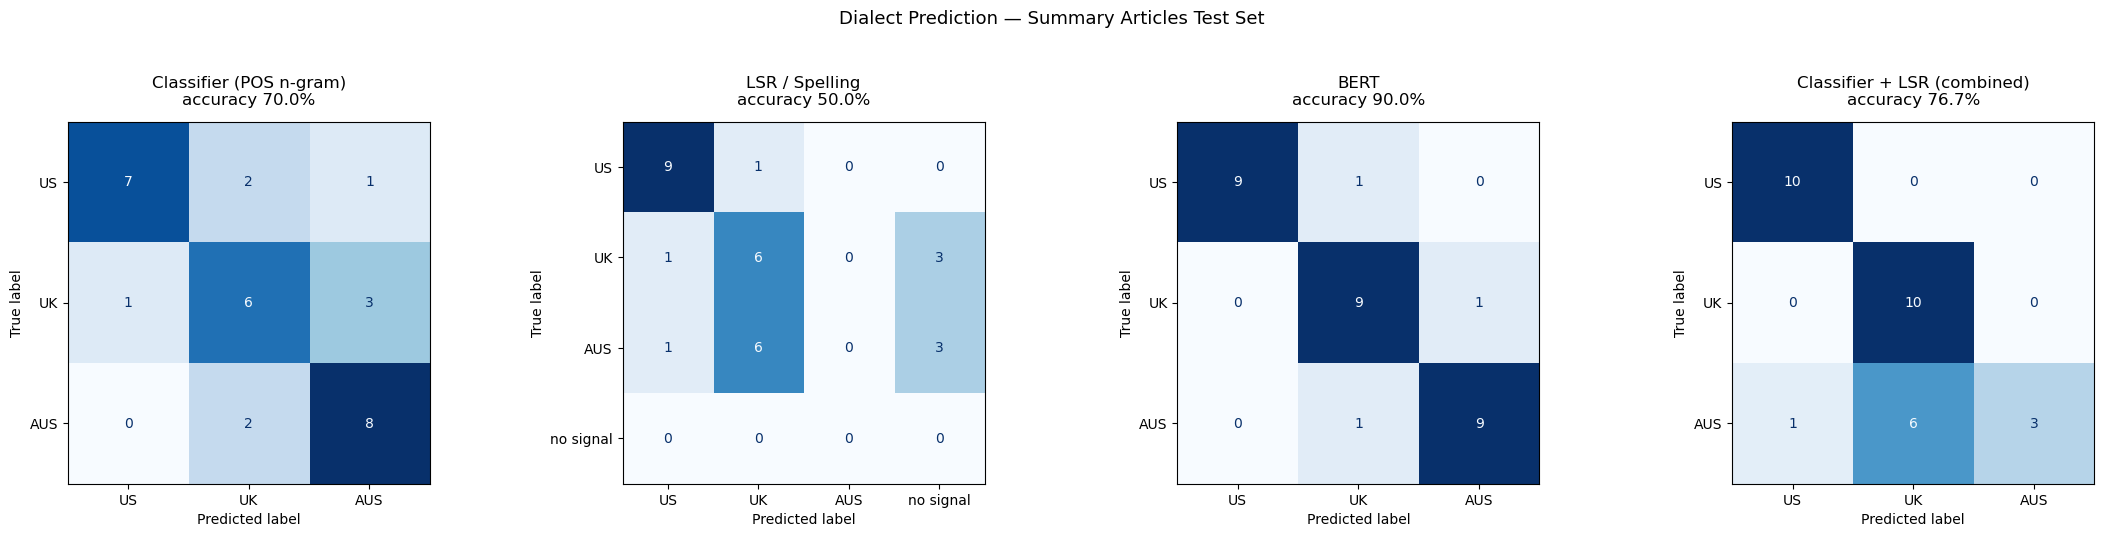

In [8]:
labels = ['US', 'UK', 'AUS']
labels_spelling = labels + ['no signal']  # spelling/LSR can abstain when an article has zero
                                           # dialect-marked words; give it its own column instead
                                           # of silently dropping those rows from the matrix

cm_clf      = confusion_matrix(df['actual'], df['pred_clf'],      labels=labels)
cm_spelling = confusion_matrix(df['actual'], df['pred_spelling'], labels=labels_spelling)
cm_bert     = confusion_matrix(df['actual'], df['pred_bert'],     labels=labels)
cm_combined = confusion_matrix(df['actual'], df['pred_combined'], labels=labels)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, cm, disp_labels, title, acc in zip(
    axes,
    [cm_clf, cm_spelling, cm_bert, cm_combined],
    [labels, labels_spelling, labels, labels],
    ['Classifier (POS n-gram)', 'LSR / Spelling', 'BERT', 'Classifier + LSR (combined)'],
    [acc_clf, acc_spelling, acc_bert, acc_combined],
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disp_labels)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'{title}\naccuracy {acc:.1%}', pad=12)

plt.suptitle('Dialect Prediction — Summary Articles Test Set', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()